In [13]:
import pandas as pd
import numpy as np

In [18]:
df_real = pd.read_csv("joint1_positions_real.csv")
df_real.head(), len(df_real)

(   joint1_pos
 0    0.000045
 1    0.000047
 2    0.000053
 3    0.004615
 4    0.029423,
 100)

In [15]:
df_sim = pd.read_csv("joint1_positions_sim.csv")
df_sim.head(), len(df_sim)

(   joint1_pos
 0    0.009531
 1    0.014534
 2    0.020416
 3    0.026812
 4    0.033556,
 100)

In [16]:
times = [0.0]*len(df)
for i in range(1, len(df)):
    times[i] = round(times[i-1] + 0.04, 2) 
times

NameError: name 'df' is not defined

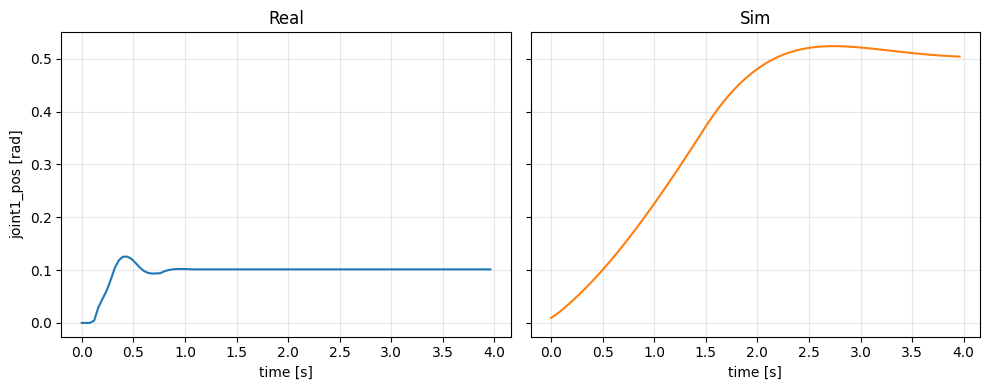

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Fix names if needed
# df_real.head(), len(df_real)
# df_sim.head(), len(df_sim)

# Build time axes (0.04 s sampling)
dt = 0.04
df_real['t'] = np.round(np.arange(len(df_real)) * dt, 2)
df_sim['t']  = np.round(np.arange(len(df_sim)) * dt, 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(df_real['t'], df_real['joint1_pos'], color='tab:blue')
axes[0].set_title('Real')
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel('joint1_pos [rad]')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sim['t'], df_sim['joint1_pos'], color='tab:orange')
axes[1].set_title('Sim')
axes[1].set_xlabel('time [s]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



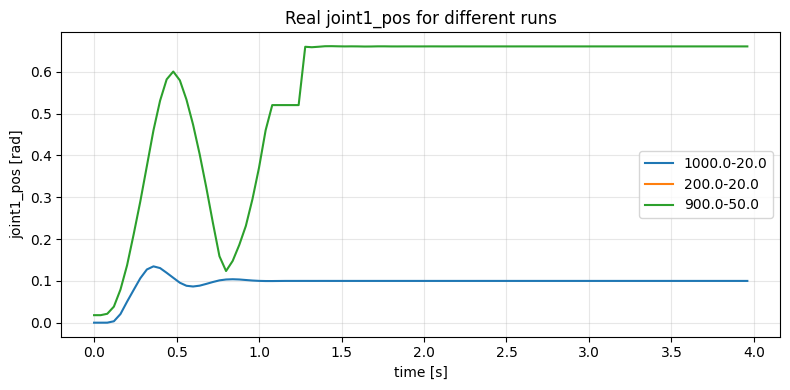

In [89]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Folder containing your CSVs
base = "/home/chemist/Desktop/ICRA2026/training/sim_to_real_analysis"
pattern = os.path.join(base, "joint1_positions_real_*.csv")
files = sorted(glob.glob(pattern))

dt = 0.04  # sampling period (s)

plt.figure(figsize=(8, 4))
for f in files:
    df = pd.read_csv(f)
    t = np.round(np.arange(len(df)) * dt, 2)
    # Label from filename, e.g., joint1_positions_real_1000.0-20.0.csv -> 1000.0-20.0
    m = re.search(r"joint1_positions_real_(.+)\.csv$", os.path.basename(f))
    label = m.group(1) if m else os.path.basename(f)
    plt.plot(t, df["joint1_pos"], label=label)

plt.xlabel("time [s]")
plt.ylabel("joint1_pos [rad]")
plt.title("Real joint1_pos for different runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()